### Install Dependencies

In [ ]:
!pip install catboost imbalanced-learn shap -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [ ]:

import pandas as pd
import numpy as np
import pickle
import os
import random
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb
import shap

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported")

✅ All libraries imported


# **Configuration**

In [ ]:

SEED             = 42
TEST_SIZE        = 0.30
CONF_THRESHOLD   = 0.70
OUTPUT_DIR       = "/content/outputs"
TOTAL_RECORDS    = 15_000
BPL_THRESHOLD    = 72_000
LABEL_NOISE_RATE = 0.13    # 13% label noise — keeps accuracy below 95%
BOUNDARY_RATIO   = 0.18    # 18% boundary/ambiguous records
PRIORITY_ORDER   = ["WP", "DP", "OAP", "NOT_ELIGIBLE"]

np.random.seed(SEED)
random.seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAT_FEATURES = [
    "gender", "marital_status", "bpl_card", "area_type",
    "social_category", "employment_status", "has_disability",
    "disability_type", "aadhaar_linked", "bank_account", "state"
]
NUM_FEATURES = ["age", "annual_income", "disability_percentage"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET       = "primary_scheme"

print("✅ Configuration set")
print(f"   Total records    : {TOTAL_RECORDS:,}")
print(f"   Label noise      : {LABEL_NOISE_RATE*100:.0f}%")
print(f"   Boundary records : {BOUNDARY_RATIO*100:.0f}%")
print(f"   Features         : {len(ALL_FEATURES)} total")
print(f"   Test size        : {TEST_SIZE*100:.0f}%")

✅ Configuration set
   Total records    : 15,000
   Label noise      : 13%
   Boundary records : 18%
   Features         : 14 total
   Test size        : 30%


# Dataset Generator

In [ ]:

# ── State profiles ───────────────────────────────────────────
STATES = {
    "Uttar Pradesh":    {"weight": 0.18, "urban_ratio": 0.22, "income_factor": 0.85},
    "Bihar":            {"weight": 0.12, "urban_ratio": 0.11, "income_factor": 0.75},
    "Madhya Pradesh":   {"weight": 0.08, "urban_ratio": 0.27, "income_factor": 0.82},
    "Rajasthan":        {"weight": 0.07, "urban_ratio": 0.24, "income_factor": 0.88},
    "West Bengal":      {"weight": 0.07, "urban_ratio": 0.31, "income_factor": 0.90},
    "Maharashtra":      {"weight": 0.06, "urban_ratio": 0.45, "income_factor": 1.10},
    "Odisha":           {"weight": 0.05, "urban_ratio": 0.16, "income_factor": 0.80},
    "Jharkhand":        {"weight": 0.05, "urban_ratio": 0.24, "income_factor": 0.78},
    "Assam":            {"weight": 0.04, "urban_ratio": 0.14, "income_factor": 0.82},
    "Andhra Pradesh":   {"weight": 0.04, "urban_ratio": 0.29, "income_factor": 0.92},
    "Tamil Nadu":       {"weight": 0.04, "urban_ratio": 0.48, "income_factor": 1.05},
    "Karnataka":        {"weight": 0.04, "urban_ratio": 0.38, "income_factor": 1.00},
    "Gujarat":          {"weight": 0.03, "urban_ratio": 0.42, "income_factor": 1.08},
    "Chhattisgarh":     {"weight": 0.03, "urban_ratio": 0.23, "income_factor": 0.80},
    "Other":            {"weight": 0.10, "urban_ratio": 0.30, "income_factor": 0.90},
}
DISABILITY_TYPES  = ["Locomotor", "Visual", "Hearing", "Mental Illness",
                      "Intellectual", "Multiple Disabilities", "Cerebral Palsy"]
SOCIAL_WEIGHTS    = {"SC": 0.25, "ST": 0.15, "OBC": 0.40, "General": 0.20}

# ── Helpers ──────────────────────────────────────────────────
def pick_state():
    s = list(STATES.keys())
    w = [STATES[x]["weight"] for x in s]
    return np.random.choice(s, p=w)

def pick_social():
    return np.random.choice(list(SOCIAL_WEIGHTS.keys()),
                             p=list(SOCIAL_WEIGHTS.values()))

def get_area(state):
    return "Urban" if np.random.random() < STATES[state]["urban_ratio"] else "Rural"

def income_bpl(state):
    # Deliberately wide — many values cluster near BPL threshold
    return int(np.random.triangular(10_000, 45_000, BPL_THRESHOLD + 15_000)
               * STATES[state]["income_factor"])

def income_above(state):
    return int(np.random.triangular(BPL_THRESHOLD + 1000, 1_50_000, 5_00_000)
               * STATES[state]["income_factor"])

def rand_aadhaar():
    return "Yes" if np.random.random() < 0.91 else "No"

def rand_bank():
    return "Yes" if np.random.random() < 0.88 else "No"

# ── True label (deterministic from features) ─────────────────
def true_label(row):
    qualifies = []
    if row["age"] >= 60 and row["bpl_card"] == "Yes":
        qualifies.append("OAP")
    if (row["gender"] == "Female" and row["marital_status"] == "Widowed"
            and 40 <= row["age"] <= 79 and row["bpl_card"] == "Yes"):
        qualifies.append("WP")
    if (row["has_disability"] == "Yes" and row["disability_percentage"] >= 40
            and 18 <= row["age"] <= 79 and row["bpl_card"] == "Yes"):
        qualifies.append("DP")
    for scheme in PRIORITY_ORDER:
        if scheme in qualifies:
            return scheme
    return "NOT_ELIGIBLE"

# ── Label noise ───────────────────────────────────────────────
CONFUSION_MAP = {
    "OAP":          ["NOT_ELIGIBLE", "WP"],
    "WP":           ["OAP", "NOT_ELIGIBLE"],
    "DP":           ["NOT_ELIGIBLE", "OAP"],
    "NOT_ELIGIBLE": ["OAP", "WP", "DP"]
}
def apply_noise(label):
    if np.random.random() < LABEL_NOISE_RATE:
        return np.random.choice(CONFUSION_MAP[label])
    return label

# ── Profile builders ─────────────────────────────────────────
def oap_profile(state):
    g   = np.random.choice(["Male", "Female"], p=[0.45, 0.55])
    wid = (g == "Female" and np.random.random() < 0.55) or \
          (g == "Male"   and np.random.random() < 0.18)
    hd  = np.random.random() < 0.12
    return {
        "age":                   int(np.random.triangular(60, 68, 90)),
        "gender":                g,
        "marital_status":        "Widowed" if wid else
                                 np.random.choice(["Married","Single","Divorced"],p=[0.65,0.25,0.10]),
        "annual_income":         income_bpl(state),
        "bpl_card":              "Yes",
        "area_type":             get_area(state),
        "social_category":       pick_social(),
        "employment_status":     np.random.choice(
                                     ["Unemployed","Self-employed","Agricultural Labour","Daily Wage"],
                                     p=[0.55,0.25,0.12,0.08]),
        "has_disability":        "Yes" if hd else "No",
        "disability_percentage": int(np.random.uniform(5, 35)) if hd else 0,
        "disability_type":       np.random.choice(DISABILITY_TYPES) if hd else "None",
        "aadhaar_linked":        rand_aadhaar(),
        "bank_account":          rand_bank(),
    }

def wp_profile(state):
    hd = np.random.random() < 0.09
    return {
        "age":                   int(np.random.triangular(40, 52, 79)),
        "gender":                "Female",
        "marital_status":        "Widowed",
        "annual_income":         income_bpl(state),
        "bpl_card":              "Yes",
        "area_type":             get_area(state),
        "social_category":       pick_social(),
        "employment_status":     np.random.choice(
                                     ["Unemployed","Self-employed","Agricultural Labour","Daily Wage"],
                                     p=[0.58,0.22,0.12,0.08]),
        "has_disability":        "Yes" if hd else "No",
        "disability_percentage": int(np.random.uniform(5, 35)) if hd else 0,
        "disability_type":       np.random.choice(DISABILITY_TYPES) if hd else "None",
        "aadhaar_linked":        rand_aadhaar(),
        "bank_account":          rand_bank(),
    }

def dp_profile(state):
    g = np.random.choice(["Male","Female"], p=[0.55,0.45])
    m = "Widowed" if (g == "Female" and np.random.random() < 0.18) else \
        np.random.choice(["Single","Married","Divorced","Widowed"], p=[0.35,0.50,0.08,0.07])
    return {
        "age":                   int(np.random.triangular(18, 38, 79)),
        "gender":                g,
        "marital_status":        m,
        "annual_income":         income_bpl(state),
        "bpl_card":              "Yes",
        "area_type":             get_area(state),
        "social_category":       pick_social(),
        "employment_status":     np.random.choice(
                                     ["Unemployed","Self-employed","Daily Wage"],
                                     p=[0.68,0.22,0.10]),
        "has_disability":        "Yes",
        "disability_percentage": int(np.random.triangular(40, 60, 100)),
        "disability_type":       np.random.choice(DISABILITY_TYPES),
        "aadhaar_linked":        rand_aadhaar(),
        "bank_account":          rand_bank(),
    }

def not_eligible_profile(state):
    g     = np.random.choice(["Male","Female"])
    vtype = np.random.choice(
        ["young","income_high","no_bpl","not_widowed","low_dis"],
        p=[0.28, 0.22, 0.20, 0.15, 0.15]
    )
    base = {"area_type": get_area(state), "social_category": pick_social(),
            "aadhaar_linked": rand_aadhaar(), "bank_account": rand_bank()}
    extras = {
        "young":       {"age": int(np.random.triangular(18,35,55)), "gender": g,
                        "marital_status": "Single", "annual_income": income_bpl(state),
                        "bpl_card": "Yes", "employment_status": "Unemployed",
                        "has_disability": "No", "disability_percentage": 0,
                        "disability_type": "None"},
        "income_high": {"age": int(np.random.triangular(45,65,85)), "gender": g,
                        "marital_status": "Married", "annual_income": income_above(state),
                        "bpl_card": "No", "employment_status": "Salaried",
                        "has_disability": "No", "disability_percentage": 0,
                        "disability_type": "None"},
        "no_bpl":      {"age": int(np.random.triangular(55,68,85)), "gender": g,
                        "marital_status": "Married", "annual_income": income_bpl(state),
                        "bpl_card": "No", "employment_status": "Agricultural Labour",
                        "has_disability": "No", "disability_percentage": 0,
                        "disability_type": "None"},
        "not_widowed": {"age": int(np.random.triangular(30,45,60)), "gender": "Female",
                        "marital_status": "Married", "annual_income": income_bpl(state),
                        "bpl_card": "Yes", "employment_status": "Unemployed",
                        "has_disability": "No", "disability_percentage": 0,
                        "disability_type": "None"},
        "low_dis":     {"age": int(np.random.triangular(20,40,70)), "gender": g,
                        "marital_status": "Single", "annual_income": income_bpl(state),
                        "bpl_card": "Yes", "employment_status": "Unemployed",
                        "has_disability": "Yes",
                        "disability_percentage": int(np.random.uniform(5, 39)),
                        "disability_type": np.random.choice(DISABILITY_TYPES)},
    }
    base.update(extras[vtype])
    return base

def boundary_profile(state):
    """Records near decision boundaries — genuinely ambiguous cases."""
    btype = np.random.choice(
        ["age_oap","age_wp","income","disability","multi"],
        p=[0.25, 0.20, 0.25, 0.20, 0.10]
    )
    g    = np.random.choice(["Male","Female"])
    base = {"area_type": get_area(state), "social_category": pick_social(),
            "aadhaar_linked": rand_aadhaar(), "bank_account": rand_bank()}

    if btype == "age_oap":
        age = int(np.random.uniform(57, 63))
        base.update({"age": age, "gender": g,
                     "marital_status": np.random.choice(["Married","Single","Widowed"],p=[0.5,0.3,0.2]),
                     "annual_income": income_bpl(state), "bpl_card": "Yes",
                     "employment_status": "Unemployed",
                     "has_disability": "No", "disability_percentage": 0,
                     "disability_type": "None"})

    elif btype == "age_wp":
        age = int(np.random.uniform(37, 43))
        base.update({"age": age, "gender": "Female", "marital_status": "Widowed",
                     "annual_income": income_bpl(state), "bpl_card": "Yes",
                     "employment_status": "Unemployed",
                     "has_disability": "No", "disability_percentage": 0,
                     "disability_type": "None"})

    elif btype == "income":
        inc = int(np.random.uniform(BPL_THRESHOLD - 8000, BPL_THRESHOLD + 8000))
        bpl = "Yes" if inc < BPL_THRESHOLD else "No"
        age = int(np.random.triangular(55, 67, 80))
        base.update({"age": age, "gender": g,
                     "marital_status": np.random.choice(["Married","Widowed"],p=[0.6,0.4]),
                     "annual_income": inc, "bpl_card": bpl,
                     "employment_status": "Agricultural Labour",
                     "has_disability": "No", "disability_percentage": 0,
                     "disability_type": "None"})

    elif btype == "disability":
        dp  = int(np.random.uniform(34, 46))
        age = int(np.random.triangular(20, 40, 70))
        base.update({"age": age, "gender": g,
                     "marital_status": np.random.choice(["Single","Married"],p=[0.5,0.5]),
                     "annual_income": income_bpl(state), "bpl_card": "Yes",
                     "employment_status": "Unemployed",
                     "has_disability": "Yes", "disability_percentage": dp,
                     "disability_type": np.random.choice(DISABILITY_TYPES)})

    else:  # multi — qualifies for multiple schemes
        base.update({"age": int(np.random.uniform(60, 75)), "gender": "Female",
                     "marital_status": "Widowed",
                     "annual_income": income_bpl(state), "bpl_card": "Yes",
                     "employment_status": "Unemployed",
                     "has_disability": "Yes",
                     "disability_percentage": int(np.random.uniform(40, 70)),
                     "disability_type": np.random.choice(DISABILITY_TYPES)})
    return base

# ── Assemble ─────────────────────────────────────────────────
print("Generating dataset...")

n_boundary = int(TOTAL_RECORDS * BOUNDARY_RATIO)
n_core     = TOTAL_RECORDS - n_boundary
dist_cfg   = {"OAP": 0.52, "WP": 0.17, "DP": 0.06, "NOT_ELIGIBLE": 0.25}
gen_map    = {"OAP": oap_profile, "WP": wp_profile,
              "DP": dp_profile, "NOT_ELIGIBLE": not_eligible_profile}

records = []

# Core records
counts = {cls: int(n_core * r) for cls, r in dist_cfg.items()}
counts["OAP"] += n_core - sum(counts.values())
for cls, count in counts.items():
    for _ in range(count):
        state = pick_state()
        rec   = gen_map[cls](state)
        rec["state"] = state
        records.append(rec)

# Boundary records
for _ in range(n_boundary):
    state = pick_state()
    rec   = boundary_profile(state)
    rec["state"] = state
    records.append(rec)

# Build DataFrame
df = pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Assign true labels then apply noise
df[TARGET] = df.apply(true_label, axis=1)
df[TARGET] = df[TARGET].apply(apply_noise)

# Add applicant ID
df.insert(0, "applicant_id",
          [f"NSAP{str(i).zfill(6)}" for i in range(1, len(df) + 1)])

# Save dataset CSV (for PPT / download)
dataset_path = f"{OUTPUT_DIR}/nsap_synthetic_dataset_v3.csv"
df.to_csv(dataset_path, index=False)

print(f"✅ Dataset generated — {len(df):,} records")
print(f"\n── Class Distribution ──────────────────────")
for cls, cnt in df[TARGET].value_counts().items():
    print(f"   {cls:<15}: {cnt:>5} ({cnt/len(df)*100:.1f}%)")
print(f"\n── Boundary records : {n_boundary:,} ({BOUNDARY_RATIO*100:.0f}%)")
print(f"   Label noise rate : {LABEL_NOISE_RATE*100:.0f}%")
print(f"\n── Sample ──────────────────────────────────")
df[["age","gender","marital_status","annual_income","bpl_card",
    "has_disability","disability_percentage",TARGET]].head(8)


Generating dataset...
✅ Dataset generated — 15,000 records

── Class Distribution ──────────────────────
   OAP            :  5148 (34.3%)
   NOT_ELIGIBLE   :  4424 (29.5%)
   WP             :  4381 (29.2%)
   DP             :  1047 (7.0%)

── Boundary records : 2,700 (18%)
   Label noise rate : 13%

── Sample ──────────────────────────────────


,age,gender,marital_status,annual_income,bpl_card,has_disability,disability_percentage,primary_scheme
0,32,Male,Single,19566,Yes,No,0,NOT_ELIGIBLE
1,60,Female,Widowed,38276,Yes,No,0,WP
2,70,Female,Married,79123,No,No,0,NOT_ELIGIBLE
3,75,Male,Married,44649,Yes,Yes,11,OAP
4,72,Female,Widowed,43435,Yes,No,0,WP
5,64,Female,Widowed,40339,Yes,No,0,WP
6,63,Female,Married,18958,Yes,No,0,OAP
7,85,Female,Widowed,31412,Yes,No,0,OAP


# Preprocessing

In [ ]:
drop_cols = ["applicant_id", "scheme_label", "all_qualifying_schemes", "multi_eligible"]
df_clean  = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in NUM_FEATURES:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in CAT_FEATURES:
    df_clean[col] = df_clean[col].fillna("Unknown")

le = LabelEncoder()
df_clean["label"] = le.fit_transform(df_clean[TARGET])

print("✅ Preprocessing complete")
print(f"\n── Label Encoding ──────────────────────────")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {cls:<15} → {enc}")

print(f"\n── Missing Values ──────────────────────────")
missing = df_clean[ALL_FEATURES].isnull().sum()
print(missing[missing > 0] if missing.any() else "   None ✅")

✅ Preprocessing complete

── Label Encoding ──────────────────────────
   DP              → 0
   NOT_ELIGIBLE    → 1
   OAP             → 2
   WP              → 3

── Missing Values ──────────────────────────
   None ✅


# Train/Test Split

In [ ]:
X = df_clean[ALL_FEATURES]
y = df_clean["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

print("✅ Data split complete")
print(f"   Train : {len(X_train):,} records")
print(f"   Test  : {len(X_test):,} records")
print(f"\n── Train Class Distribution ────────────────")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls} ({le.classes_[cls]}): {cnt}")

✅ Data split complete
   Train : 10,500 records
   Test  : 4,500 records

── Train Class Distribution ────────────────
   Class 0 (DP): 733
   Class 1 (NOT_ELIGIBLE): 3097
   Class 2 (OAP): 3603
   Class 3 (WP): 3067


# SMOTE

In [ ]:

print("Applying SMOTE to training set only...")

X_train_enc  = X_train.copy()
temp_encoders = {}
for col in CAT_FEATURES:
    le_temp = LabelEncoder()
    X_train_enc[col] = le_temp.fit_transform(X_train_enc[col].astype(str))
    temp_encoders[col] = le_temp

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_resampled_enc, y_resampled = smote.fit_resample(X_train_enc, y_train)

X_train_bal = X_resampled_enc.copy()
for col in CAT_FEATURES:
    le_temp = temp_encoders[col]
    indices = X_resampled_enc[col].round().astype(int).clip(0, len(le_temp.classes_) - 1)
    X_train_bal[col] = le_temp.inverse_transform(indices)

print("✅ SMOTE complete")
print(f"\n── Before SMOTE ────────────────────────────")
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f"   Class {cls} ({le.classes_[cls]}): {cnt}")
print(f"\n── After SMOTE ─────────────────────────────")
for cls, cnt in zip(*np.unique(y_resampled, return_counts=True)):
    print(f"   Class {cls} ({le.classes_[cls]}): {cnt}")

Applying SMOTE to training set only...
✅ SMOTE complete

── Before SMOTE ────────────────────────────
   Class 0 (DP): 733
   Class 1 (NOT_ELIGIBLE): 3097
   Class 2 (OAP): 3603
   Class 3 (WP): 3067

── After SMOTE ─────────────────────────────
   Class 0 (DP): 3603
   Class 1 (NOT_ELIGIBLE): 3603
   Class 2 (OAP): 3603
   Class 3 (WP): 3603


# CatBoost Training

In [ ]:

print("Training CatBoost...")

cat_feature_indices = [
    X_train_bal.columns.get_loc(c)
    for c in CAT_FEATURES if c in X_train_bal.columns
]

cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.04,    # lowered from 0.05 — reduces overconfident predictions
    depth=5,               # reduced from 6 — less overfitting, better generalization
    loss_function="MultiClass",
    eval_metric="Accuracy",
    cat_features=cat_feature_indices,
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=50,
    l2_leaf_reg=5,         # added — increased regularization reduces false eligible rate
    # Note: class_weights removed — SMOTE already balances all classes.
    # Previous {2:3.0} was upweighting OAP (majority class, index 2 in label encoding)
    # not DP (minority), which was incorrectly inflating false eligible rates.
)

cb_model.fit(
    X_train_bal, y_resampled,
    eval_set=(X_test, y_test),
    use_best_model=True
)
print("\n✅ CatBoost training complete")


Training CatBoost...
0:	learn: 0.8262559	test: 0.8262222	best: 0.8262222 (0)	total: 331ms	remaining: 2m 45s
100:	learn: 0.8685817	test: 0.8628889	best: 0.8631111 (97)	total: 23.2s	remaining: 1m 31s
200:	learn: 0.8716347	test: 0.8637778	best: 0.8640000 (198)	total: 37.2s	remaining: 55.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8644444444
bestIteration = 216

Shrink model to first 217 iterations.

✅ CatBoost training complete


# Baseline Models

In [ ]:

print("Training baseline models...")

X_train_num   = X_train_bal.copy()
X_test_num    = X_test.copy()
baseline_encoders = {}

for col in CAT_FEATURES:
    le_temp = LabelEncoder()
    X_train_num[col] = le_temp.fit_transform(X_train_num[col].astype(str))
    X_test_num[col]  = le_temp.transform(
        X_test_num[col].astype(str).map(
            lambda x: x if x in le_temp.classes_ else le_temp.classes_[0]
        )
    )
    baseline_encoders[col] = le_temp

# XGBoost
print("\n   Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    objective="multi:softprob", num_class=4,
    random_state=SEED, verbosity=0, eval_metric="mlogloss",
)
xgb_model.fit(X_train_num, y_resampled)
print("   ✅ XGBoost done")

# LightGBM
print("\n   Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    objective="multiclass", num_class=4,
    random_state=SEED, verbose=-1,
)
lgb_model.fit(X_train_num, y_resampled)
print("   ✅ LightGBM done")

# Logistic Regression
print("\n   Training Logistic Regression...")
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000, random_state=SEED,
        multi_class="multinomial", solver="lbfgs",
    ))
])
lr_model.fit(X_train_num, y_resampled)
print("   ✅ Logistic Regression done")

print("\n✅ All baseline models trained")


Training baseline models...

   Training XGBoost...
   ✅ XGBoost done

   Training LightGBM...
   ✅ LightGBM done

   Training Logistic Regression...
   ✅ Logistic Regression done

✅ All baseline models trained


# Model Evaluation

In [ ]:

def evaluate(model, name, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if isinstance(y_pred[0], (list, np.ndarray)):
        y_pred = np.array([p[0] for p in y_pred])
    y_pred = y_pred.astype(int)

    acc  = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_eval, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_eval, y_pred, average="weighted", zero_division=0)
    f1pc = f1_score(y_eval, y_pred, average=None, zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\n{classification_report(y_eval, y_pred, target_names=le.classes_, zero_division=0)}")

    return {
        "Model": name, "Accuracy": round(acc, 4),
        "Precision": round(prec, 4), "Recall": round(rec, 4),
        "F1_Weighted": round(f1, 4),
        **{f"F1_{cls}": round(f1pc[i], 4) for i, cls in enumerate(le.classes_)}
    }, y_pred

cb_metrics,  y_pred_cb  = evaluate(cb_model,  "CatBoost",            X_test,     y_test)
xgb_metrics, y_pred_xgb = evaluate(xgb_model, "XGBoost",             X_test_num, y_test)
lgb_metrics, y_pred_lgb = evaluate(lgb_model, "LightGBM",            X_test_num, y_test)
lr_metrics,  y_pred_lr  = evaluate(lr_model,  "Logistic Regression", X_test_num, y_test)

all_metrics   = [cb_metrics, xgb_metrics, lgb_metrics, lr_metrics]
df_comparison = pd.DataFrame(all_metrics).sort_values("F1_Weighted", ascending=False)

print("\n\n── Final Model Comparison ──────────────────────────────────")
print(df_comparison.to_string(index=False))
df_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv", index=False)



  CatBoost
  Accuracy  : 0.8644
  Precision : 0.8644
  Recall    : 0.8644
  F1 Score  : 0.8642

              precision    recall  f1-score   support

          DP       0.83      0.81      0.82       314
NOT_ELIGIBLE       0.87      0.83      0.85      1327
         OAP       0.87      0.89      0.88      1545
          WP       0.87      0.87      0.87      1314

    accuracy                           0.86      4500
   macro avg       0.86      0.85      0.85      4500
weighted avg       0.86      0.86      0.86      4500


  XGBoost
  Accuracy  : 0.8638
  Precision : 0.8636
  Recall    : 0.8638
  F1 Score  : 0.8635

              precision    recall  f1-score   support

          DP       0.84      0.79      0.81       314
NOT_ELIGIBLE       0.86      0.84      0.85      1327
         OAP       0.87      0.89      0.88      1545
          WP       0.87      0.87      0.87      1314

    accuracy                           0.86      4500
   macro avg       0.86      0.85      0.85   

# Confusion Matrix

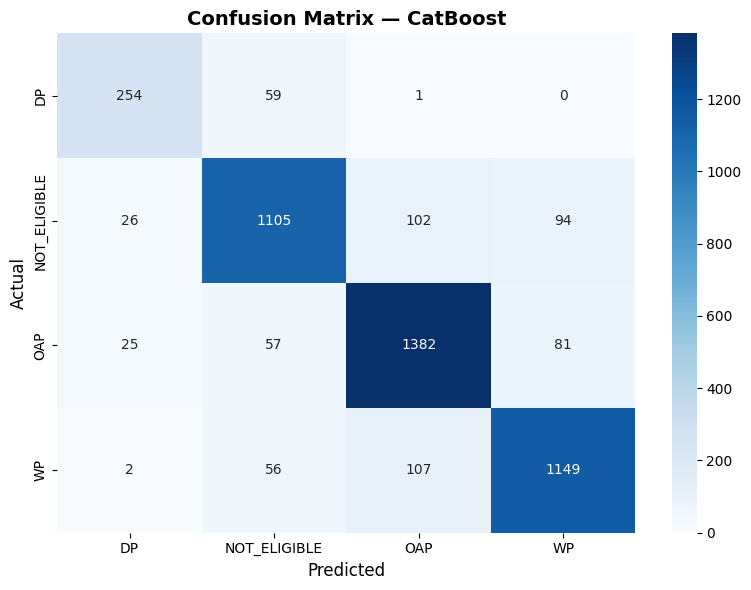

✅ Saved: /content/outputs/confusion_matrix_catboost.png


In [ ]:
cm = confusion_matrix(y_test, y_pred_cb)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title("Confusion Matrix — CatBoost", fontsize=14, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12)
ax.set_xlabel("Predicted", fontsize=12)
plt.tight_layout()

save_path = f"{OUTPUT_DIR}/confusion_matrix_catboost.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {save_path}")

# SHAP Feature Importance

Generating SHAP explanations (this may take a minute)...


<Figure size 640x480 with 0 Axes>

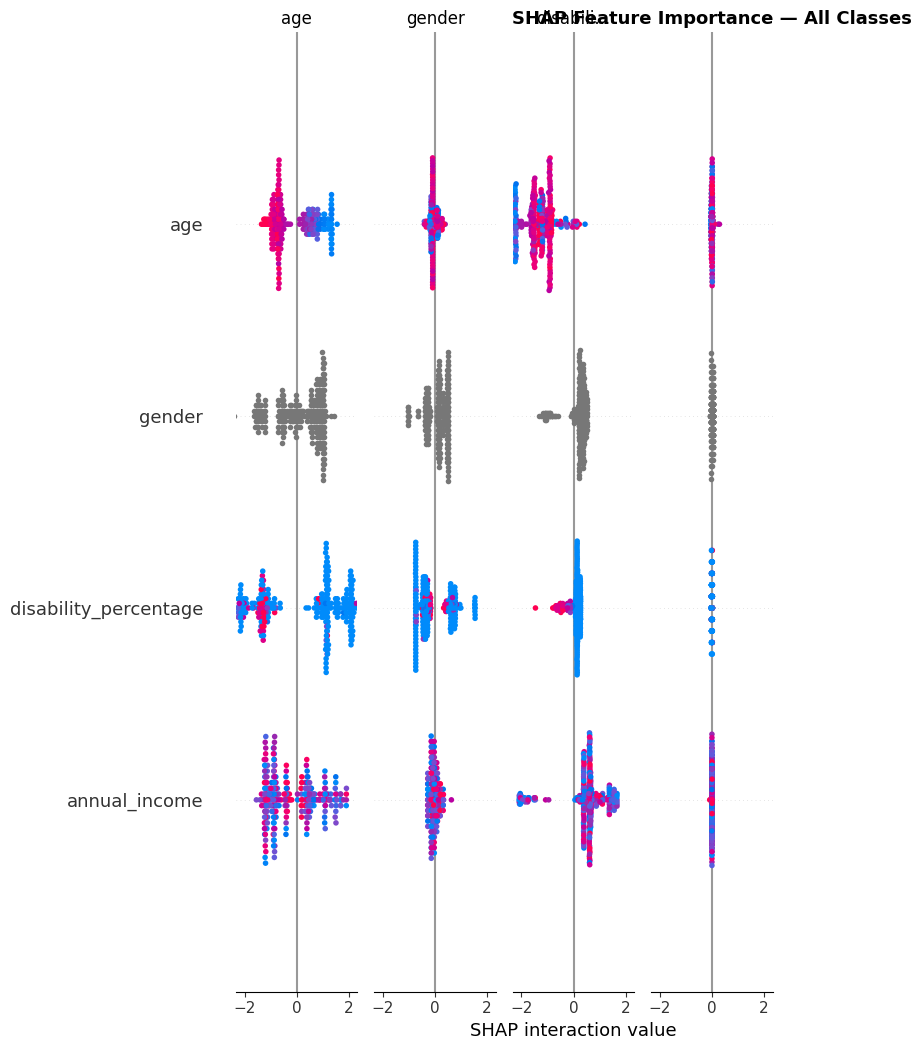

✅ SHAP plot saved


In [ ]:
print("Generating SHAP explanations (this may take a minute)...")

X_sample    = X_test.sample(300, random_state=SEED)
explainer   = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    class_names=list(le.classes_),
    show=False, max_display=12
)
plt.title("SHAP Feature Importance — All Classes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SHAP plot saved")


# Fairness Analysis

In [ ]:
# Tracks two critical error types per demographic group:
#
#   False Not-Eligible Rate → eligible person wrongly DENIED
#                             (model says NOT_ELIGIBLE, truth is a scheme)
#                             High value = model is unfairly excluding people
#
#   False Eligible Rate     → ineligible person wrongly APPROVED
#                             (model says a scheme, truth is NOT_ELIGIBLE)
#                             High value = model is approving non-qualifiers
# ────────────────────────────────────────────────────────────

not_eligible_label = list(le.classes_).index("NOT_ELIGIBLE")
results = []

X_test_reset = X_test.reset_index(drop=True)
y_test_arr   = np.array(y_test).flatten()
y_pred_arr   = np.array(y_pred_cb).flatten()

for group_col in ["gender", "area_type", "social_category"]:
    for grp in X_test_reset[group_col].unique():
        mask = X_test_reset[group_col] == grp
        if mask.sum() < 30:
            continue
        grp_pred = y_pred_arr[mask]
        grp_true = y_test_arr[mask]

        not_elig_rate  = (grp_pred == not_eligible_label).mean()
        error_rate     = (grp_pred != grp_true).mean()

        # Wrongly denied — eligible but predicted NOT_ELIGIBLE
        false_not_elig = (
            (grp_pred == not_eligible_label) &
            (grp_true != not_eligible_label)
        ).mean()

        # Wrongly approved — NOT_ELIGIBLE but predicted a scheme
        false_eligible = (
            (grp_pred != not_eligible_label) &
            (grp_true == not_eligible_label)
        ).mean()

        # Flag if either error rate exceeds 5%
        flag = []
        if false_not_elig > 0.05:
            flag.append("⚠ High Denial")
        if false_eligible > 0.05:
            flag.append("⚠ High Approval")
        flag_str = " | ".join(flag) if flag else "✓ OK"

        results.append({
            "Group_Column":            group_col,
            "Group":                   grp,
            "Count":                   int(mask.sum()),
            "Not_Eligible_Rate":       round(not_elig_rate, 4),
            "Error_Rate":              round(error_rate, 4),
            "False_Not_Eligible_Rate": round(false_not_elig, 4),
            "False_Eligible_Rate":     round(false_eligible, 4),
            "Flag":                    flag_str,
        })

df_fairness = pd.DataFrame(results)
df_fairness.to_csv(f"{OUTPUT_DIR}/fairness_report.csv", index=False)

print("✅ Fairness Report")
print(f"\n── Column Guide ────────────────────────────────────────────")
print(f"   False_Not_Eligible_Rate : eligible person wrongly DENIED")
print(f"   False_Eligible_Rate     : ineligible person wrongly APPROVED")
print(f"   Flag threshold          : > 5% triggers ⚠ warning")
print(f"\n── Results ─────────────────────────────────────────────────")
print(df_fairness.to_string(index=False))

# ── Overall model-level rates (not per group) ─────────────────
overall_false_not_elig = (
    (y_pred_arr == not_eligible_label) &
    (y_test_arr != not_eligible_label)
).mean()

overall_false_elig = (
    (y_pred_arr != not_eligible_label) &
    (y_test_arr == not_eligible_label)
).mean()

print(f"\n── Overall Model Rates ─────────────────────────────────────")
print(f"   False Not-Eligible Rate : {overall_false_not_elig:.4f} "
      f"({overall_false_not_elig*100:.1f}%) — eligible wrongly denied")
print(f"   False Eligible Rate     : {overall_false_elig:.4f} "
      f"({overall_false_elig*100:.1f}%) — ineligible wrongly approved")



✅ Fairness Report

── Column Guide ────────────────────────────────────────────
   False_Not_Eligible_Rate : eligible person wrongly DENIED
   False_Eligible_Rate     : ineligible person wrongly APPROVED
   Flag threshold          : > 5% triggers ⚠ warning

── Results ─────────────────────────────────────────────────
   Group_Column   Group  Count  Not_Eligible_Rate  Error_Rate  False_Not_Eligible_Rate  False_Eligible_Rate            Flag
         gender  Female   2857             0.2639      0.1386                   0.0392               0.0497            ✓ OK
         gender    Male   1643             0.3183      0.1302                   0.0365               0.0487            ✓ OK
      area_type   Rural   3299             0.2868      0.1340                   0.0397               0.0485            ✓ OK
      area_type   Urban   1201             0.2756      0.1399                   0.0341               0.0516 ⚠ High Approval
social_category      ST    668             0.2635      0.1407

# Save Model Artifact

In [ ]:
cb_model.save_model(f"{OUTPUT_DIR}/nsap_catboost_model.cbm")

with open(f"{OUTPUT_DIR}/nsap_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

with open(f"{OUTPUT_DIR}/nsap_feature_columns.pkl", "wb") as f:
    pickle.dump(ALL_FEATURES, f)

print("✅ All artifacts saved")
print(f"\n── Saved Files ─────────────────────────────")
for fname in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(f"{OUTPUT_DIR}/{fname}")
    print(f"   {fname:<50} {size/1024:.1f} KB")


✅ All artifacts saved

── Saved Files ─────────────────────────────
   confusion_matrix_catboost.png                      50.9 KB
   nsap_synthetic_dataset_v3.csv                      1431.4 KB
   shap_summary.png                                   180.6 KB
   nsap_feature_columns.pkl                           0.2 KB
   nsap_catboost_model.cbm                            365.2 KB
   nsap_label_encoder.pkl                             0.3 KB
   model_comparison.csv                               0.3 KB
   fairness_report.csv                                0.6 KB


# Test Prediction

In [ ]:
def predict_applicant(applicant_data, label=""):
    df_input    = pd.DataFrame([applicant_data])[ALL_FEATURES]
    proba       = cb_model.predict_proba(df_input)[0]
    class_names = list(le.classes_)

    qualifying = [
        class_names[i] for i, p in enumerate(proba)
        if p >= CONF_THRESHOLD and class_names[i] != "NOT_ELIGIBLE"
    ]
    primary    = "NOT_ELIGIBLE"
    confidence = float(np.max(proba))
    for scheme in PRIORITY_ORDER:
        if scheme in qualifying:
            primary    = scheme
            confidence = float(proba[class_names.index(scheme)])
            break

    if label:
        print(f"\n{'─'*45}")
        print(f"  {label}")
        print(f"{'─'*45}")
    print(f"   Primary Scheme : {primary}")
    print(f"   Confidence     : {confidence*100:.1f}%")
    print(f"   All Qualifying : {qualifying if qualifying else 'None'}")
    print(f"   Needs Review   : {'Yes' if confidence < CONF_THRESHOLD else 'No'}")
    print(f"\n   All Probabilities:")
    for cls, p in sorted(zip(class_names, proba), key=lambda x: -x[1]):
        bar = "█" * int(p * 25)
        print(f"   {cls:<15}: {p:.4f} {bar}")

predict_applicant({
    "age": 68, "gender": "Female", "marital_status": "Widowed",
    "annual_income": 35000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "SC", "employment_status": "Unemployed",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Uttar Pradesh"
}, "TEST 1 — Elderly Widow (expect WP)")

predict_applicant({
    "age": 35, "gender": "Male", "marital_status": "Single",
    "annual_income": 28000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "ST", "employment_status": "Unemployed",
    "has_disability": "Yes", "disability_percentage": 65,
    "disability_type": "Locomotor", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Bihar"
}, "TEST 2 — Disabled Applicant (expect DP)")

predict_applicant({
    "age": 55, "gender": "Male", "marital_status": "Married",
    "annual_income": 250000, "bpl_card": "No", "area_type": "Urban",
    "social_category": "General", "employment_status": "Salaried",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Maharashtra"
}, "TEST 3 — Not Eligible (income too high)")

predict_applicant({
    "age": 59, "gender": "Male", "marital_status": "Married",
    "annual_income": 69000, "bpl_card": "Yes", "area_type": "Rural",
    "social_category": "OBC", "employment_status": "Agricultural Labour",
    "has_disability": "No", "disability_percentage": 0,
    "disability_type": "None", "aadhaar_linked": "Yes",
    "bank_account": "Yes", "state": "Rajasthan"
}, "TEST 4 — Boundary Case (age 59, income near BPL threshold)")


─────────────────────────────────────────────
  TEST 1 — Elderly Widow (expect WP)
─────────────────────────────────────────────
   Primary Scheme : WP
   Confidence     : 84.6%
   All Qualifying : ['WP']
   Needs Review   : No

   All Probabilities:
   WP             : 0.8456 █████████████████████
   OAP            : 0.0951 ██
   NOT_ELIGIBLE   : 0.0576 █
   DP             : 0.0017 

─────────────────────────────────────────────
  TEST 2 — Disabled Applicant (expect DP)
─────────────────────────────────────────────
   Primary Scheme : DP
   Confidence     : 92.9%
   All Qualifying : ['DP']
   Needs Review   : No

   All Probabilities:
   DP             : 0.9292 ███████████████████████
   NOT_ELIGIBLE   : 0.0430 █
   OAP            : 0.0212 
   WP             : 0.0066 

─────────────────────────────────────────────
  TEST 3 — Not Eligible (income too high)
─────────────────────────────────────────────
   Primary Scheme : NOT_ELIGIBLE
   Confidence     : 78.9%
   All Qualifying : None


# Download all files

In [ ]:

from google.colab import files

download_files = [
    f"{OUTPUT_DIR}/nsap_synthetic_dataset_v3.csv",      # dataset for PPT
    f"{OUTPUT_DIR}/model_comparison.csv",                # metrics table
    f"{OUTPUT_DIR}/confusion_matrix_catboost.png",       # confusion matrix plot
    f"{OUTPUT_DIR}/shap_summary.png",                    # SHAP plot
    f"{OUTPUT_DIR}/fairness_report.csv",                 # fairness analysis
    f"{OUTPUT_DIR}/nsap_catboost_model.cbm",             # trained model
    f"{OUTPUT_DIR}/nsap_label_encoder.pkl",              # label encoder
    f"{OUTPUT_DIR}/nsap_feature_columns.pkl",            # feature list
]

print("Downloading all files...")
for fpath in download_files:
    if os.path.exists(fpath):
        files.download(fpath)
        print(f"✅ {os.path.basename(fpath)}")
    else:
        print(f"⚠  Not found: {os.path.basename(fpath)}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ nsap_synthetic_dataset_v3.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ nsap_label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ nsap_feature_columns.pkl
